In [1]:
# Imports

import os
from dotenv import load_dotenv
from typing import TypedDict

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END

from sentence_transformers import CrossEncoder

In [2]:
# Load Environment
load_dotenv()

True

In [3]:
# Embeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Load Constitution Vector DB

DB_PATH = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\vector_database"

constitution_db = Chroma(
    persist_directory=DB_PATH,
    embedding_function=embeddings,
    collection_name="legal_knowledge"
)

print("Total constitution chunks:", constitution_db._collection.count())

Total constitution chunks: 787


In [5]:
# Document Chunking Function

def split_documents(docs, embeddings, debug=False):

    structure_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1800,
        chunk_overlap=250,
        separators=[
            r"\n\s*ISSUE",
            r"\n\s*FACTS",
            r"\n\s*BACKGROUND",
            r"\n\s*ARGUMENT",
            r"\n\s*ANALYSIS",
            r"\n\s*HOLDING",
            r"\n\s*ORDER",
            r"\n\s*JUDGMENT",
            r"\n\s*RELIEF",
            r"\n\s*Article\s+\d+",
            r"\n\s*Section\s+\d+",
            r"\n\s*\d+\.",
            r"\n\s*\(\d+\)",
            "\n\n",
            "\n",
            " "
        ],
        is_separator_regex=True
    )

    structured_docs = structure_splitter.split_documents(docs)

    try:
        semantic_splitter = SemanticChunker(embeddings)
        semantic_docs = semantic_splitter.split_documents(structured_docs)
    except:
        semantic_docs = structured_docs

    final_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500,
        chunk_overlap=250
    )

    final_docs = final_splitter.split_documents(semantic_docs)

    return final_docs

In [6]:
# Load Uploaded Document function

from langchain_community.vectorstores import Chroma

def load_uploaded_document(file_path):

    loader = PyPDFLoader(file_path)
    docs = loader.load()

    chunks = split_documents(docs, embeddings)

    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name="uploaded_doc"
    )

    print("Uploaded document indexed:", len(chunks))

    return vector_store

In [7]:
# Legal Knowledge Retrieval function

def retrieve_legal_docs(query, k=5):

    docs = constitution_db.similarity_search(
        f"{query} legal principle",
        k=k
    )

    return docs

In [8]:
# Graph State

from typing import TypedDict, Optional, Any

class LegalState(TypedDict):
    question: str
    strategy: str
    plan: Optional[str]

    legal_context: Optional[str]
    document_context: Optional[str]

    document_db: Optional[Any]  # vector store for uploaded PDF

    answer: Optional[str]

In [9]:
# Cross Encoder Reranker

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# Uploaded Document Retrieval function

def retrieve_document_docs(state: LegalState, k=15):

    vector_store = state.get("document_db")

    if vector_store is None:
        return []

    query = state["question"]

    docs = vector_store.similarity_search(query, k=k)

    pairs = [[query, d.page_content] for d in docs]

    scores = reranker.predict(pairs)

    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)

    return [doc for doc,_ in ranked[:5]]

In [11]:
# LLM 

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [12]:
# Strategist Agent

def strategist_agent(state: LegalState):

    question = state["question"]

    prompt = f"""
You are a legal strategist.

Decide the best research strategy.

Possible strategies:
- legal (use Indian law knowledge base)
- document (use uploaded case document)
- both (use both sources)

Respond ONLY in this format:

Strategy: <legal | document | both>
Reason: <short explanation>

Question:
{question}
"""

    response = llm.invoke(prompt)
    output = response.content

    # Extract strategy safely
    strategy = "legal"

    if "both" in output.lower():
        strategy = "both"
    elif "document" in output.lower():
        strategy = "document"
    elif "legal" in output.lower():
        strategy = "legal"

    return {
        "strategy": strategy,
        "plan": output
    }

In [13]:
# Legal Research Agent

def legal_research_agent(state: LegalState):

    docs = retrieve_legal_docs(state["question"])

    context = "\n\n".join([d.page_content for d in docs])

    return {"legal_context": context}

In [14]:
# Document Research Agent

def document_research_agent(state: LegalState):

    docs = retrieve_document_docs(state, k=20)

    if len(docs) == 0:
        return {"document_context": ""}

    context = "\n\n".join([d.page_content for d in docs])

    return {"document_context": context}

In [15]:
# Advisor Agent

def advisor_agent(state: LegalState):

    question = state["question"]

    legal_context = state.get("legal_context", "")
    document_context = state.get("document_context", "")

    prompt = f"""
You are an expert Indian legal advisor.

Answer the question using the provided context.

If the answer is not present in the context,
say the information is not available.

LEGAL CONTEXT:
{legal_context}

DOCUMENT CONTEXT:
{document_context}

QUESTION:
{question}

Provide a clear explanation.
"""

    response = llm.invoke(prompt)

    return {"answer": response.content}

In [16]:
from langgraph.graph import StateGraph, END

# Initialize the workflow
workflow = StateGraph(LegalState)

# Add Nodes
workflow.add_node("strategist", strategist_agent)
workflow.add_node("legal_research", legal_research_agent)
workflow.add_node("document_research", document_research_agent)
workflow.add_node("advisor", advisor_agent)

# Set the Entry Point
workflow.set_entry_point("strategist")

# Updated Routing Function for Parallel Execution
def route_research(state: LegalState):
    """
    Determines the next step(s) in the workflow. 
    Returning a list triggers parallel execution in LangGraph.
    """
    strategy = state.get("strategy", "").lower()

    if "both" in strategy:
        # This triggers BOTH nodes to run simultaneously
        return ["legal_research", "document_research"]
    
    if "document" in strategy or "uploaded" in strategy:
        return ["document_research"]
    
    # Default to legal research
    return ["legal_research"]

# Updated Conditional Routing
# We no longer need the mapping dictionary because the function 
# returns the exact node names to visit.
workflow.add_conditional_edges(
    "strategist",
    route_research
)

# Connect the research nodes to the final advisor
# Note: LangGraph automatically handles the 'join' if both were running in parallel
workflow.add_edge("legal_research", "advisor")
workflow.add_edge("document_research", "advisor")

# Final step
workflow.add_edge("advisor", END)

# Compile the graph
legal_graph = workflow.compile()

print("Graph successfully updated with parallel routing logic.")

Graph successfully updated with parallel routing logic.


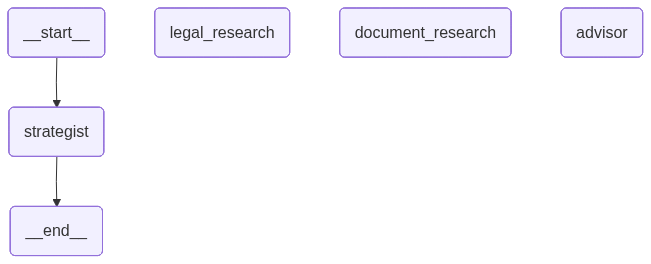

In [17]:
from IPython.display import Image, display

display(Image(legal_graph.get_graph().draw_mermaid_png()))

In [18]:
# RAG Main Agent Function

def legal_agentic_rag(question, uploaded_file=None):

    vector_store = None

    if uploaded_file is not None:
        vector_store = load_uploaded_document(uploaded_file)

    result = legal_graph.invoke({
        "question": question,
        "document_db": vector_store
    })

    return result["answer"]

In [19]:
print(
    legal_agentic_rag(
        "If a state law conflicts with a central law in India, which one prevails?"
    )
)

According to Article 251 of the Constitution of India, if a state law conflicts with a central law, the central law prevails. This means that if a provision of a state law is repugnant to a provision of a central law, the central law will take precedence, and the state law will be inoperative to the extent of the repugnancy.

In other words, if there is a conflict between a state law and a central law, the central law will override the state law, and the state law will not be applicable as long as the central law remains in effect.

This is a fundamental principle of Indian constitutional law, which ensures that the central laws take precedence over state laws in cases of conflict, maintaining the unity and integrity of the country.

To summarize:

* Central law prevails over state law in case of conflict
* State law is inoperative to the extent of repugnancy with central law
* Central law takes precedence over state law, ensuring unity and integrity of the country.


In [22]:
# File path of the uploaded case document
document_path = r"C:/Users/user/Desktop/RAG Projects/Legal RAG 1/data/Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF"

# Index the uploaded PDF and create a temporary vector store
uploaded_vector_store = load_uploaded_document(document_path)

# Test questions designed to validate document-specific retrieval
document_tests = [
    #("Who is the plaintiff in this case?", "Vandana Dhirani", "Validate extraction of key parties."),
    ("What is the CS DJ number of this suit?", "588/2021", "Verify retrieval of case identification details."),
    #("What was the outcome of the suit declared on 27.07.2023?", "Dismissed", "Confirm correct identification of the case result."),
    #("What does Issue No. 8 address?", "Interest", "Check recognition of specific legal issues."),
    ("Who presided as the judge at Saket Courts in this matter?", "Navjeet Budhiraja", "Verify judge name extraction."),
    #("Did the court grant recovery of arrears of rent?", "not found entitled", "Validate core judgment conclusions."),
    ("On which floor is property C-99 situated?", "4th Floor", "Check extraction of property-related details."),
    #("When was this suit officially instituted?", "31.08.2021", "Verify procedural timeline retrieval."),
    ("What justification did the defendant give for non-payment of rent in Issue 4?", "force majeure", "Check defense argument extraction (Covid / Force Majeure)."),
    #("Did the court order preparation of a decree sheet?", "Decree sheet be prepared", "Confirm recognition of final court directives.")
]

print("\n--- EXECUTING DOCUMENT RETRIEVAL TESTS ---\n")

for i, (question, expected_key, explanation) in enumerate(document_tests):

    # Run the RAG system with the uploaded document vector store
    answer = legal_agentic_rag(question, uploaded_file=document_path)

    # Initial evaluation check
    result_status = "PASS" if expected_key.lower() in answer.lower() else "FAIL"

    # Flexible checks for alternative phrasing or synonyms
    if result_status == "FAIL":
        if "dismiss" in answer.lower() and expected_key.lower() == "dismissed":
            result_status = "PASS (Synonym Match)"
        elif "not entitled" in answer.lower() and expected_key.lower() == "not found entitled":
            result_status = "PASS (Synonym Match)"
        elif "saket" in answer.lower() and expected_key.lower() == "navjeet budhiraja":
            result_status = "FAIL (Partial Match)"

    print(f"DOCUMENT TEST #{i+1}")
    print(f"Question: {question}")
    print(f"Model Answer: {answer.strip()}")
    print(f"Evaluation Result: {result_status} (Expected Key: {expected_key})")
    print(f"Test Purpose: {explanation}")
    print("-" * 60)

Uploaded document indexed: 120

--- EXECUTING DOCUMENT RETRIEVAL TESTS ---

Uploaded document indexed: 120
DOCUMENT TEST #1
Question: What is the CS DJ number of this suit?
Model Answer: The CS DJ number of this suit is 588/2021. 

This information is available in the provided context, where it is mentioned as "1 CS DJ NO.588/2021" in each of the judgment sections. The "CS DJ NO." refers to the case number, and "588/2021" is the specific number assigned to this suit.
Evaluation Result: PASS (Expected Key: 588/2021)
Test Purpose: Verify retrieval of case identification details.
------------------------------------------------------------
Uploaded document indexed: 120


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99506, Requested 1401. Please try again in 13m3.648s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

# Benchmark set for evaluating general legal knowledge retrieval
# Each test includes:
# (question, expected_keyword, evaluation_note)

general_tests = [

    ("Under what circumstances can a Writ of Habeas Corpus be issued in India?",
     "Article 32",
     "Checks understanding of constitutional remedies and enforcement of fundamental rights."),

    ("What legal penalty exists for drunk driving under the Motor Vehicles Act?",
     "Section 185",
     "Verifies retrieval of specific statutory provisions."),

    ("Does the Constitution of India recognize the right to privacy?",
     "Puttaswamy",
     "Evaluates whether the system references the landmark privacy judgment."),

    ("How many members can the President nominate to the Rajya Sabha?",
     "12",
     "Tests factual constitutional knowledge regarding parliamentary composition."),

    ("Which article of the Constitution establishes the Finance Commission?",
     "Article 280",
     "Validates knowledge of constitutional administrative bodies."),

    ("Is a person allowed to be prosecuted twice for the same offence in India?",
     "Double Jeopardy",
     "Tests recognition of the Article 20(2) constitutional protection."),

    ("What is the minimum age required to become the Prime Minister of India?",
     "25",
     "Checks eligibility requirements linked to Lok Sabha membership."),

    ("Is the Right to Property still considered a Fundamental Right in India?",
     "300A",
     "Tests awareness of the 44th Constitutional Amendment change."),

    ("Which article of the Indian Constitution abolishes untouchability?",
     "Article 17",
     "Assesses understanding of core fundamental rights."),

    ("Can Fundamental Rights be suspended during a National Emergency?",
     "Article 359",
     "Evaluates knowledge of emergency provisions affecting rights.")
]

print("\n--- RUNNING GENERAL LEGAL KNOWLEDGE TESTS ---\n")


for i, (question, keyword, explanation) in enumerate(general_tests):

    response = legal_agentic_rag(question)

    answer = response.lower()

    # Primary keyword check
    status = "PASS" if keyword.lower() in answer else "FAIL"

    # Flexible checks for common variations
    if status == "FAIL":

        if "jeopardy" in answer and keyword.lower() == "double jeopardy":
            status = "PASS (Synonym)"

        elif "privacy" in answer and keyword.lower() == "puttaswamy":
            status = "PASS (Concept Match)"

        elif "property" in answer and keyword.lower() == "300a":
            status = "PASS (Concept Match)"

    print(f"TEST #{i+1}")
    print(f"Question: {question}")
    print(f"AI Answer: {response.strip()}")
    print(f"Result: {status} (Expected Keyword: {keyword})")
    print(f"Test Objective: {explanation}")
    print("-" * 60)